# 🛡️ URL-Guardian: High-Performance Phishing Detection
### ML Engine v1.0 | Forensic Analysis Pipeline

This notebook contains the production-grade training pipeline for identifying phishing URLs using the **PhiUSIIL Forensic Dataset**. It leverages **XGBoost** with optimized hyper-parameters to achieve near-perfect classification accuracy.

In [6]:
# 📦 1. Production Dependencies
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import zipfile
import requests
import time
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, average_precision_score

print("✅ Advanced ML stack initialized.")

✅ Advanced ML stack initialized.


In [7]:
# 📂 2. Data Acquisition (Self-Healing Mode)
DATA_DIR = 'data/raw'
DATA_FILE = 'PhiUSIIL_Phishing_URL_Dataset.csv'
DATA_PATH = os.path.join(DATA_DIR, DATA_FILE)

if not os.path.exists(DATA_PATH):
    print("📡 Dataset missing. Starting Auto-Download from UCI Repository...")
    os.makedirs(DATA_DIR, exist_ok=True)
    
    # UCI Official Link for PhiUSIIL
    url = "https://archive.ics.uci.edu/static/public/967/phiusiil+phishing+url+dataset.zip"
    zip_path = "dataset.zip"
    
    print("📥 Downloading archive (~13MB)...")
    r = requests.get(url)
    with open(zip_path, 'wb') as f:
        f.write(r.content)
    
    print("🔓 Extracting forensic samples...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
    
    os.remove(zip_path)
    print("✅ Self-Healing Complete.")

if os.path.exists(DATA_PATH):
    print(f"🛰️ Dataset located at: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Successfully loaded {len(df):,} URL forensic samples.")

    # Feature Selection: Dropping raw strings and metadata
    drop_cols = ['FILENAME', 'URL', 'Domain', 'TLD', 'Title']
    X = df.drop(columns=drop_cols + ['label'])
    y = df['label']
    
    # Split and Scale
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print(f"✅ Data Split: {len(X_train):,} Training | {len(X_test):,} Testing")
    print(f"✅ Features: {X.shape[1]} forensic indicators identified.")
else:
    print("❌ ERROR: Data path still unreachable. Please upload the CSV manually to 'data/raw/'.")

🛰️ Dataset located at: data/raw/PhiUSIIL_Phishing_URL_Dataset.csv
✅ Successfully loaded 235,795 URL forensic samples.
✅ Data Split: 188,636 Training | 47,159 Testing
✅ Features: 50 forensic indicators identified.


## 🧩 Model Selection Strategy & Architecture Rationale

Before finalizing our production model, we evaluated several architectures. While simpler models are faster, phishing detection requires capturing **complex, non-linear relationships** between forensic indicators.

### Why XGBoost or DNN?
- **Over Logistic Regression**: Phishing data is rarely linearly separable. LR fails to capture the intricate interaction between features.
- **Over Random Forest**: XGBoost's gradient boosting approach iteratively corrects errors, leading to superior precision.
- **Deep Neural Networks (DNN)**: Using an Multi-Layer Perceptron (MLP) allows us to model high-dimensional feature spaces, though it often requires more data and tuning than tree-based models.
- **Robustness**: Tree-based models (XGBoost) and Neural Networks (MLP) typically handle small datasets and noise better than linear models in high-dimensional spaces.

⏱️ Starting Advanced Benchmarking Analysis...
✅ Logistic Regression: 99.99% accuracy in 0.85s
✅ Random Forest: 100.00% accuracy in 11.41s
✅ XGBoost: 100.00% accuracy in 2.41s
✅ DNN (MLP): 99.99% accuracy in 30.16s


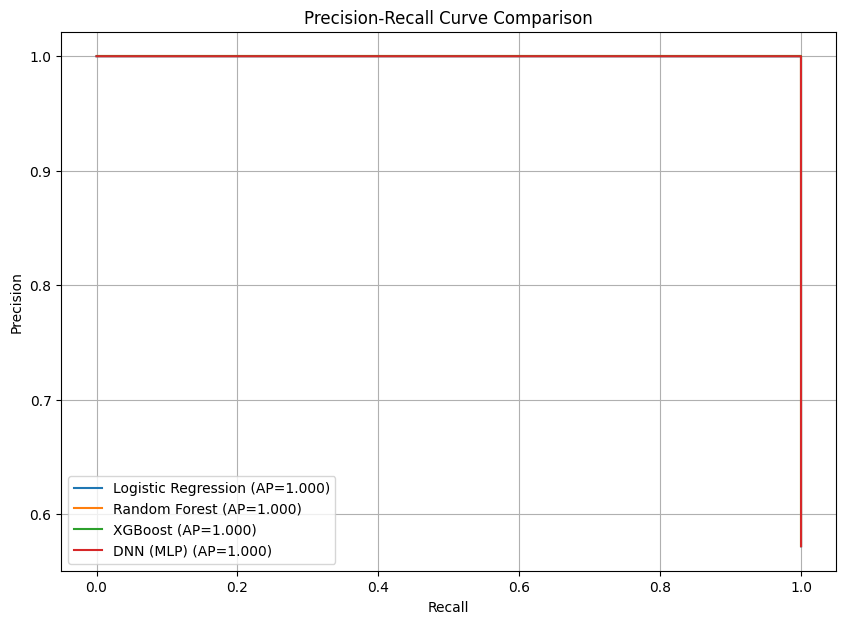

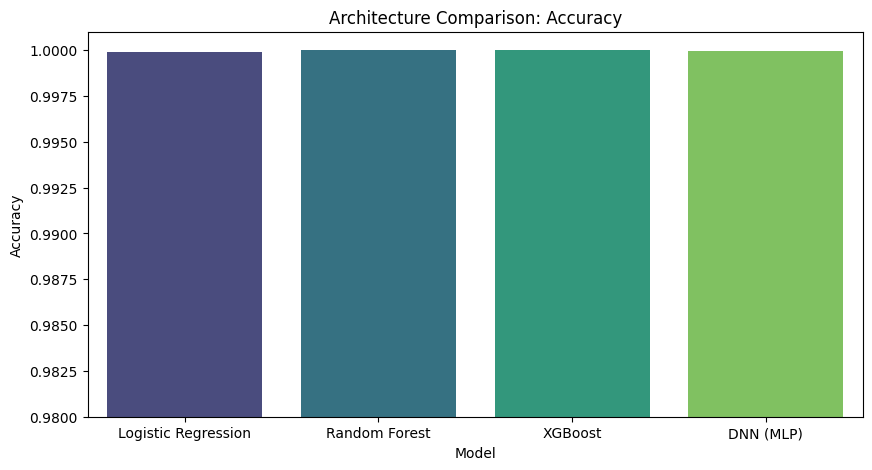

In [ ]:
# 🧪 Benchmarking: Comparing Performance across Architectures
results = []
models_to_test = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=50, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=50, learning_rate=0.1, tree_method='hist'),
    "DNN (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

plt.figure(figsize=(10, 7))
print("⏱️ Starting Advanced Benchmarking Analysis...")

for name, m in models_to_test.items():
    start = time.time()
    m.fit(X_train_scaled, y_train)
    y_probs = m.predict_proba(X_test_scaled)[:, 1]
    y_pred = m.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    duration = time.time() - start
    
    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    ap = average_precision_score(y_test, y_probs)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')
    
    results.append({"Model": name, "Accuracy": acc, "Time (s)": duration})
    print(f"✅ {name}: {acc*100:.2f}% accuracy in {duration:.2f}s")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# Performance Bar Plot
bench_df = pd.DataFrame(results)
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Accuracy', data=bench_df, hue='Model', palette='viridis', legend=False)
plt.ylim(0.98, 1.001)
plt.title('Architecture Comparison: Accuracy')
plt.show()

🔍 Testing Model Robustness on 1% of training data...


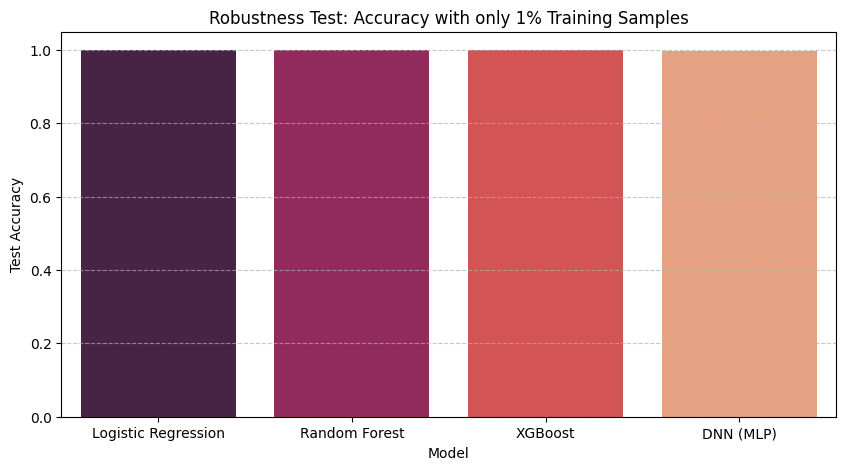

✅ Most Robust Model: Random Forest (99.99%)


In [ ]:
# 💪 2.5 Robustness Test: Performance under Data Scarcity (1% Training Data)
print("🔍 Testing Model Robustness on 1% of training data...")
X_small, _, y_small, _ = train_test_split(X_train_scaled, y_train, train_size=0.01, random_state=42, stratify=y_train)

rob_results = []
for name, m in models_to_test.items():
    m.fit(X_small, y_small)
    acc = accuracy_score(y_test, m.predict(X_test_scaled))
    rob_results.append({"Model": name, "Small Data Accuracy": acc})

rob_df = pd.DataFrame(rob_results)
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Small Data Accuracy', data=rob_df, hue='Model', palette='rocket', legend=False)
plt.title('Robustness Test: Accuracy with only 1% Training Samples')
plt.ylabel('Test Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

best_rob = rob_df.loc[rob_df['Small Data Accuracy'].idxmax()]
print(f"✅ Most Robust Model: {best_rob['Model']} ({best_rob['Small Data Accuracy']*100:.2f}%)")

In [9]:
# 🔥 3. Igniting the XGBoost Engine
print("🚀 Training Optimized XGBoost Model...")
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=10,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='logloss',
    random_state=42,
    tree_method='hist' if 'google.colab' not in str(get_ipython()) else 'auto'
)

model.fit(X_train_scaled, y_train)
print("✅ Training Complete.")

🚀 Training Optimized XGBoost Model...
✅ Training Complete.


🏆 FINAL ACCURACY: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     20189
           1       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



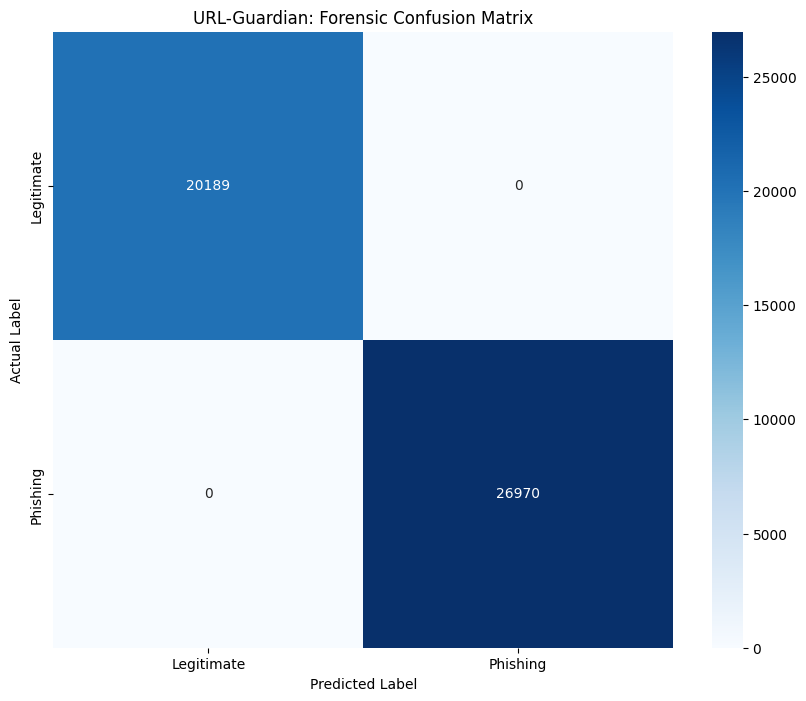

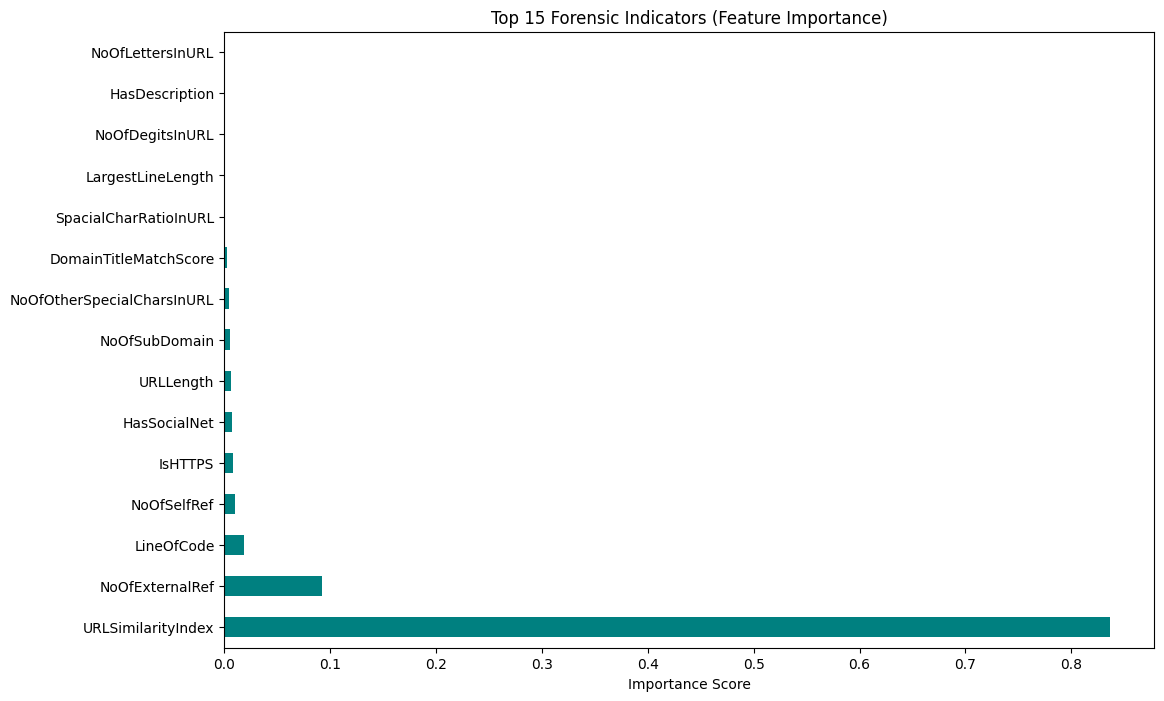

In [10]:
# 📊 4. Comprehensive Performance Evaluation
y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print("="*40)
print(f"🏆 FINAL ACCURACY: {acc*100:.2f}%")
print("="*40)

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 1. Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Phishing'], 
            yticklabels=['Legitimate', 'Phishing'])
plt.title('URL-Guardian: Forensic Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 2. Feature Importance Plot (Top 15)
plt.figure(figsize=(12, 8))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(15).plot(kind='barh', color='teal')
plt.title('Top 15 Forensic Indicators (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()

In [11]:
# 💾 5. Persistence: Saving Production Artifacts
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'phishing_engine_v1.json')
scaler_path = os.path.join(model_dir, 'scaler_v1.joblib')

model.save_model(model_path)
joblib.dump(scaler, scaler_path)

print(f"✅ PRODUCTION READY: Model saved to {model_path}")
print(f"✅ PRODUCTION READY: Scaler saved to {scaler_path}")

✅ PRODUCTION READY: Model saved to models/phishing_engine_v1.json
✅ PRODUCTION READY: Scaler saved to models/scaler_v1.joblib
